In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('placement.csv')

In [5]:
df.shape

(1000, 3)

In [6]:
df.sample(5)

,cgpa,placement_exam_marks,placed
561,7.07,58.0,0
116,7.16,21.0,0
904,7.36,32.0,0
352,6.51,4.0,1
877,6.32,9.0,0


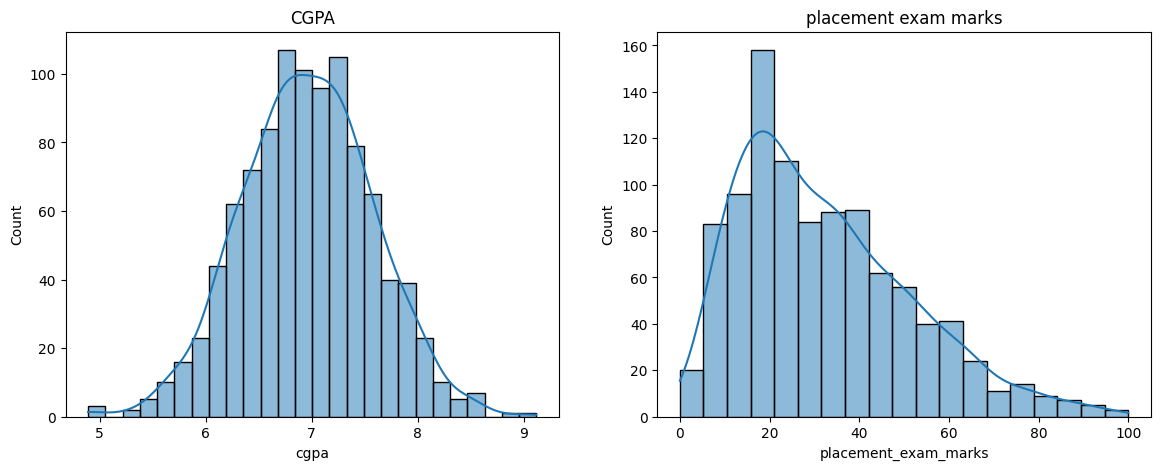

In [18]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1 )
sns.histplot(df['cgpa'],kde=True)
plt.title('CGPA')
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.title('placement exam marks')
plt.show()


In [19]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [ ]:
#finding boundary values
high_std = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_std = df['cgpa'].mean() - 3*df['cgpa'].std()
print(high_std)
print(lower_std)

8.808933625397168
5.113546374602832


In [31]:
#outliers
df[(df['cgpa'] > 8.8)  |( df['cgpa'] < 5.1)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [37]:
new_df = df[(df['cgpa'] < 8.8)  & ( df['cgpa'] > 5.1)]
new_df.shape

(995, 3)

In [38]:
#z_score 
df['z_score'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [39]:
df.head()

,cgpa,placement_exam_marks,placed,z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [40]:
df[(df['z_score'] > +3  ) | (df['z_score'] < -3)]

,cgpa,placement_exam_marks,placed,z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [44]:
z_df = df[(df['z_score'] < +3  ) & (df['z_score'] > -3)]
z_df.shape

(995, 4)

capping

In [48]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [52]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
    
)

In [53]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64